# R30 — Per-Encoder MLP with Rich Metadata + Inter-Eye Features — Referable Glaucoma

Same per-encoder pipeline as R28/R29 — **NO cross-encoder fusion** — each of the 7 encoders
is evaluated independently with its own MLP.

| Aspect | R29 (baseline) | R30 (this experiment) |
|---|---|---|
| Encoders | 7 × single (independent) | 7 × single (independent) |
| PCA | 384 per encoder | 384 per encoder |
| Metadata features | 5 (age, sex, diabetes, camera, exam_eye) | **18** (+ clinical findings + image quality + pathology flags) |
| Inter-eye features | None | **35** (cos_delta, l2 × 7 encoders) + 4 norm stats |
| Target | referable_glaucoma (bilateral ≥ 2) | same |
| Model | MLP (BayesSearchCV + 25-bag) | MLP (BayesSearchCV + 25-bag) |
| Best R29 F1 | 0.721 (dinov3_vitb16) | Target: ≥ 0.80 |

**Key improvements over R29 (same pipeline, richer features):**
1. **Rich metadata (18 vs 5)** — vessels, macula, image quality (focus/illumination/artifacts/field), DR_ICDR, pathology flags
2. **Inter-eye asymmetry features (39)** — pre-computed cosine/L2 distance between OD and OS per encoder + norm stats
3. **Same per-encoder MLP loop** — identical to R28/R29, no cross-encoder fusion

In [1]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 1 — Imports
# ═══════════════════════════════════════════════════════════════════════

import json, time, warnings, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.collections import LineCollection

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    f1_score, roc_auc_score, roc_curve,
    precision_score, recall_score, balanced_accuracy_score,
    confusion_matrix, classification_report,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedShuffleSplit
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

sys.path.insert(0, str(Path.cwd() / 'src'))
from retina_embeddings_dataset import load_retina_embeddings_dataset

plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')
np.random.seed(42)

print('R30 imports OK')

R30 imports OK


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 2 — Configuration
# ═══════════════════════════════════════════════════════════════════════

DATASET_NAME = 'brset'
TASK         = 'referable_glaucoma'
TASK_SOURCE  = 'increased_cup_disc'
RANDOM_SEED  = 42

from multiprocessing import cpu_count
CPU_COUNT = cpu_count()

# ─── Paths ────────────────────────────────────────────────────────
BASE_DIR     = Path.cwd()
FE_DIR       = BASE_DIR / 'artifacts' / 'brset_eda_fe'
EMBED_DIR    = BASE_DIR / 'data' / 'brset_embeddings'
LABELS_PATH  = EMBED_DIR / 'brset_labels' / 'labels_brset.csv'
RESULTS_DIR  = BASE_DIR / 'results' / 'brset_r30_rich_meta_referable_glaucoma'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# R29 baseline for comparison
R29_SUMMARY  = BASE_DIR / 'results' / 'brset_r29_referable_glaucoma' / 'r29_per_encoder' / 'r29_summary.csv'

# ─── Architecture search space (same as R28/R29) ─────────────────
ARCHITECTURE_OPTIONS = [
    (128,), (256,), (512,),
    (256, 128), (512, 256), (512, 128),
    (256, 128, 64), (512, 256, 128),
    (128, 64), (384, 192),
    (384, 192, 96),
]

SEARCH_SPACE = {
    'hidden_layer_sizes': Categorical(list(range(len(ARCHITECTURE_OPTIONS)))),
    'alpha': Real(1e-3, 1.0, prior='log-uniform'),
    'learning_rate_init': Real(1e-4, 2e-3, prior='log-uniform'),
    'batch_size': Categorical([64, 128, 256]),
    'pos_class_weight': Real(1.0, 10.0, prior='uniform'),
}

# ─── Pipeline parameters ─────────────────────────────────────────
PCA_COMPONENTS       = 384
MI_SELECTION         = True
MI_PERCENTILE_THRESH = 0.30          # ↑ from 0.15 to filter more aggressively
MI_MIN_COMPONENTS    = 128

BAYES_N_ITER   = 30
BAYES_CV_FOLDS = 3
BAYES_N_JOBS   = min(CPU_COUNT - 1, 6)
MLP_MAX_ITER   = 400
MLP_PATIENCE   = 30

BAG_SEEDS           = [42, 123, 314, 555, 789]
N_BAG_ARCH_VARIANTS = 5
N_BAGS = len(BAG_SEEDS) * N_BAG_ARCH_VARIANTS  # 25

CALIBRATE       = True
DUAL_THRESHOLD  = True
AGG_METHODS     = ['mean', 'max', 'noisy_or', 'mean_top_2', 'mean_top_3', 'trimmed_mean']
THRESHOLD_GRID  = 301
THRESHOLD_FLOOR = 0.05

# ─── Rich metadata (18 features vs 5 in R29) ─────────────────────
METADATA_COLS = {
    # Demographics (R29 had these 5)
    'age':         'numeric',
    'sex':         'passthrough',    # 1=M, 2=F
    'diabetes':    'binary_yn',
    'exam_eye':    'binary',         # 1=OD, 2=OS -> 0/1
    'camera':      'camera',         # Canon/Nikon -> 0/1
    # Clinical findings (NEW in R30)
    'vessels':     'binary',         # 1=normal, 2=abnormal
    'macula':      'binary',         # 1=normal, 2=abnormal
    # Image quality features (NEW in R30)
    'quality':     'quality',        # Adequate/Inadequate -> 0/1
    'focus':       'binary',         # 1=good, 2=bad
    'iluminaton':  'binary',         # 1=good, 2=bad (orig spelling)
    'artifacts':   'binary',         # 1=no, 2=yes
    'image_field': 'binary',         # 1=good, 2=poor
    # Other pathology flags — different pathways, not leaky (NEW)
    'DR_ICDR':     'passthrough',    # 0-4 ordinal
    'macular_edema':           'passthrough',  # 0/1
    'hemorrhage':              'passthrough',  # 0/1
    'hypertensive_retinopathy':'passthrough',  # 0/1
    'drusens':                 'passthrough',  # 0/1
    'scar':                    'passthrough',  # 0/1
}

# ─── NO optic_disc masking ────────────────────────────────────────
# Removed: OD masking adds noise for bilateral (referable) glaucoma
# detection since optic_disc tells about THIS eye, not bilateral status.
# The model should rely on embedding features + inter-eye asymmetry.

print(f'FE artifacts:  {FE_DIR}')
print(f'Embeddings:    {EMBED_DIR}')
print(f'Results:       {RESULTS_DIR}')
print(f'Task:          {TASK} (derived from {TASK_SOURCE})')
print(f'PCA: {PCA_COMPONENTS} | MI: drop <{MI_PERCENTILE_THRESH:.0%} | min {MI_MIN_COMPONENTS}')
print(f'Metadata cols: {len(METADATA_COLS)} (vs 5 in R29)')
print(f'BayesSearchCV: {BAYES_N_ITER} iters, {BAYES_CV_FOLDS}-fold, scoring=f1')
print(f'Bagging: {len(BAG_SEEDS)} seeds x {N_BAG_ARCH_VARIANTS} variants = {N_BAGS}')
print(f'OD masking: DISABLED (not informative for bilateral detection)')

FE artifacts:  c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\artifacts\brset_eda_fe
Embeddings:    c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings
Results:       c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r30_rich_meta_referable_glaucoma
Task:          referable_glaucoma (derived from increased_cup_disc)
PCA: 384 | MI: drop <30% | min 128
Metadata cols: 18 (vs 5 in R29)
BayesSearchCV: 30 iters, 3-fold, scoring=f1
Bagging: 5 seeds x 5 variants = 25
OD masking: DISABLED (not informative for bilateral detection)


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 3 — Load Data + FE Artifacts + Label Derivation
# ═══════════════════════════════════════════════════════════════════════

# ─── FE engineered features (inter-eye distances + norm stats) ────
fe_df = pd.read_csv(FE_DIR / 'features_engineered_image_level.csv')
fe_df['patient_id'] = fe_df['patient_id'].astype(str)

# ─── 3-way patient split ─────────────────────────────────────────
splits = pd.read_csv(FE_DIR / 'splits_patient.csv')
splits['patient_id'] = splits['patient_id'].astype(str)

train_pids = set(splits[splits['split'] == 'train']['patient_id'])
val_pids   = set(splits[splits['split'] == 'val']['patient_id'])
test_pids  = set(splits[splits['split'] == 'test']['patient_id'])

assert len(train_pids & val_pids)  == 0, 'Train/val patient leakage!'
assert len(train_pids & test_pids) == 0, 'Train/test patient leakage!'
assert len(val_pids   & test_pids) == 0, 'Val/test patient leakage!'

# ─── Labels for clinical metadata ────────────────────────────────
labels_raw = pd.read_csv(LABELS_PATH)
labels_raw['patient_id'] = labels_raw['patient_id'].astype(str)
labels_raw = labels_raw.rename(columns={'patient_age': 'age', 'patient_sex': 'sex'})

# ─── Derive referable_glaucoma label (bilateral >= 2) ────────────
glau_img = labels_raw[['image_id', 'patient_id', TASK_SOURCE]].dropna(subset=[TASK_SOURCE])
glau_img[TASK_SOURCE] = glau_img[TASK_SOURCE].astype(int)
pat_sum  = glau_img.groupby('patient_id')[TASK_SOURCE].sum()
pat_label_map = (pat_sum >= 2).astype(int).to_dict()  # bilateral = referable

labels_raw[TASK] = labels_raw['patient_id'].map(pat_label_map).fillna(0).astype(int)

n_total = len(pat_sum)
n_zero  = (pat_sum == 0).sum()
n_uni   = (pat_sum == 1).sum()
n_bi    = (pat_sum >= 2).sum()
print(f'Label derivation:')
print(f'  Total patients:       {n_total}')
print(f'  No glaucoma:          {n_zero} ({n_zero/n_total:.1%})')
print(f'  Unilateral (suspect): {n_uni} ({n_uni/n_total:.1%})')
print(f'  Bilateral (REF+):     {n_bi} ({n_bi/n_total:.1%})')

# ─── Inter-eye feature columns from FE file ──────────────────────
IE_COLS = [c for c in fe_df.columns
           if any(s in c for s in ['cos_delta', 'cos_neg', 'cos_pos', '__l2'])]
NORM_COLS = [c for c in fe_df.columns if c.startswith('norm_')]

# ─── Merge FE inter-eye features with labels metadata ────────────
meta_keep = ['image_id', 'age', 'sex', 'diabetes', 'exam_eye', 'camera',
             'optic_disc', 'vessels', 'macula', 'quality', 'focus', 'iluminaton',
             'artifacts', 'image_field', 'DR_ICDR', 'macular_edema',
             'hemorrhage', 'hypertensive_retinopathy', 'drusens', 'scar',
             TASK]
fe_full = fe_df.merge(labels_raw[meta_keep], on='image_id', how='left')

# ─── Embedding files (per-encoder evaluation) ────────────────────
embedding_files = sorted(EMBED_DIR.glob('Embeddings_*.csv'))

print(f'\nPatient split:      {len(train_pids)} train / {len(val_pids)} val / {len(test_pids)} test')
print(f'Inter-eye features: {len(IE_COLS)} cols')
print(f'Norm features:      {len(NORM_COLS)} cols')
print(f'Rich metadata:      {len(METADATA_COLS)} cols')
print(f'Embedding files:    {len(embedding_files)}')
for f in embedding_files:
    print(f'  {f.name}')

Label derivation:
  Total patients:       8524
  No glaucoma:          6500 (76.3%)
  Unilateral (suspect): 849 (10.0%)
  Bilateral (REF+):     1175 (13.8%)

Patient split:      5796 train / 1023 val / 1705 test
Inter-eye features: 35 cols
Norm features:      4 cols
Rich metadata:      18 cols
Embedding files:    7
  Embeddings_brset_convnextv2_base_.csv
  Embeddings_brset_dinov3_convnext_base.csv
  Embeddings_brset_dinov3_vitb16.csv
  Embeddings_brset_RETFound_dinov2_shanghai.csv
  Embeddings_brset_RETFound_mae_natureCFP.csv
  Embeddings_brset_RETFound_mae_shanghai.csv
  Embeddings_brset_vit_base_.csv


In [4]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 4 — Helper Functions
# ═══════════════════════════════════════════════════════════════════════

def short_name(path):
    stem = Path(path).stem
    for s in ['Embeddings_brset_', 'Embeddings_']:
        stem = stem.replace(s, '')
    return stem


def make_sample_weights(y, pos_class_weight=1.0):
    y = np.asarray(y)
    w = np.where(y == 1, float(pos_class_weight), 1.0).astype(np.float32)
    mean_w = w.mean()
    if mean_w > 0:
        w /= mean_w
    return w


def find_optimal_threshold(y_true, y_proba, grid_size=301, floor=0.05):
    thresholds = np.linspace(floor, 0.99, grid_size)
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        if preds.sum() == 0:
            continue
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def mi_select_features(X_train, y_train, X_others,
                       percentile_thresh=0.15, min_components=128,
                       random_state=42):
    mi_scores = mutual_info_classif(
        X_train, y_train, discrete_features=False,
        n_neighbors=5, random_state=random_state,
    )
    threshold = np.percentile(mi_scores, percentile_thresh * 100)
    mask = mi_scores >= threshold
    if mask.sum() < min_components:
        top_k = np.argsort(mi_scores)[-min_components:]
        mask = np.zeros(len(mi_scores), dtype=bool)
        mask[top_k] = True
    X_train_sel = X_train[:, mask]
    X_others_sel = [X[:, mask] for X in X_others]
    return X_train_sel, X_others_sel, mask, mi_scores


class MLPWrapperForBayesSearch(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=0, alpha=0.01,
                 learning_rate_init=0.001, batch_size=64,
                 pos_class_weight=1.0, max_iter=400,
                 early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=30, random_state=42, warm_start=False):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.pos_class_weight = pos_class_weight
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.warm_start = warm_start
        self._mlp = None

    def _get_architecture(self):
        if isinstance(self.hidden_layer_sizes, int):
            return ARCHITECTURE_OPTIONS[self.hidden_layer_sizes]
        return self.hidden_layer_sizes

    def fit(self, X, y, sample_weight=None):
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch, alpha=self.alpha,
            learning_rate='adaptive',
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size, max_iter=self.max_iter,
            early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state,
            warm_start=self.warm_start,
        )
        sw = make_sample_weights(y, pos_class_weight=self.pos_class_weight)
        self._mlp.fit(X, y, sample_weight=sw)
        self.classes_ = self._mlp.classes_
        return self

    def predict(self, X): return self._mlp.predict(X)
    def predict_proba(self, X): return self._mlp.predict_proba(X)


def aggregate_patient_proba(pids, proba, method='mean'):
    df = pd.DataFrame({'patient': pids, 'proba': proba})
    if method == 'mean':
        return df.groupby('patient')['proba'].mean()
    elif method == 'max':
        return df.groupby('patient')['proba'].max()
    elif method == 'noisy_or':
        return df.groupby('patient')['proba'].apply(
            lambda x: 1.0 - np.prod(1.0 - x.values.clip(0, 0.9999)))
    elif method == 'mean_top_2':
        return df.groupby('patient')['proba'].apply(
            lambda x: np.sort(x.values)[-2:].mean() if len(x) >= 2 else x.max())
    elif method == 'mean_top_3':
        return df.groupby('patient')['proba'].apply(
            lambda x: np.sort(x.values)[-3:].mean() if len(x) >= 3
                      else (np.sort(x.values)[-2:].mean() if len(x) >= 2 else x.max()))
    elif method == 'trimmed_mean':
        return df.groupby('patient')['proba'].apply(
            lambda x: np.sort(x.values)[1:].mean() if len(x) >= 3 else x.mean())
    raise ValueError(f'Unknown method: {method}')


def aggregate_patient_labels(pids, labels):
    df = pd.DataFrame({'patient': pids, 'label': labels})
    return df.groupby('patient')['label'].max()


def encode_metadata(df, metadata_cols, fit_stats=None):
    if fit_stats is None:
        fit_stats = {}
    meta_parts = []
    for col, dtype in metadata_cols.items():
        if col not in df.columns:
            print(f'    WARNING: metadata col {col!r} not found, skipping')
            continue
        vals = df[col].copy()
        if dtype == 'numeric':
            vals = pd.to_numeric(vals, errors='coerce')
            if 'median_' + col not in fit_stats:
                fit_stats['median_' + col] = float(vals.median())
            vals = vals.fillna(fit_stats['median_' + col])
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary':
            vals = pd.to_numeric(vals, errors='coerce').fillna(1)
            vals = (vals - 1).clip(0, 1)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'passthrough':
            vals = pd.to_numeric(vals, errors='coerce').fillna(0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary_yn':
            vals = vals.astype(str).str.lower().map({'yes': 1.0, 'no': 0.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'camera':
            vals = vals.astype(str).map({'Canon CR': 0.0, 'NIKON NF5050': 1.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'quality':
            vals = vals.astype(str).map({'Adequate': 0.0, 'Inadequate': 1.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
    if not meta_parts:
        return np.zeros((len(df), 0), dtype=np.float32), fit_stats
    return np.hstack(meta_parts), fit_stats


def encode_inter_eye_features(df, ie_cols, norm_cols, fit_stats=None):
    """Encode inter-eye distance features + norm stats from FE file."""
    if fit_stats is None:
        fit_stats = {}
    parts = []
    for col in ie_cols + norm_cols:
        if col not in df.columns:
            continue
        vals = pd.to_numeric(df[col], errors='coerce')
        med_key = 'median_ie_' + col
        if med_key not in fit_stats:
            fit_stats[med_key] = float(vals.median()) if not vals.isna().all() else 0.0
        vals = vals.fillna(fit_stats[med_key])
        parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
    if not parts:
        return np.zeros((len(df), 0), dtype=np.float32), fit_stats
    return np.hstack(parts), fit_stats


def make_wider(arch, factor=1.5):
    return tuple(max(64, int(x * factor)) for x in arch)

def make_deeper(arch):
    return arch + (max(64, arch[-1] // 2),)

def make_narrower(arch, factor=0.67):
    return tuple(max(64, int(x * factor)) for x in arch)

def make_shallower(arch):
    if len(arch) > 1:
        return arch[:-1]
    return (max(64, arch[0] // 2),)


def _bin_od(series):
    return (pd.to_numeric(series, errors='coerce') == 2).astype(np.float32).to_numpy()

def _mask_od(od_series, p_mask, rng, p_corrupt=0.0):
    od = _bin_od(od_series)
    if p_mask >= 1.0:
        miss = np.ones(len(od), dtype=bool)
    elif p_mask > 0:
        miss = rng.random(len(od)) < p_mask
    else:
        miss = np.zeros(len(od), dtype=bool)
    od_m = od.copy()
    od_m[miss] = 0.0
    if p_corrupt and p_corrupt > 0:
        corrupt = (~miss) & (rng.random(len(od)) < p_corrupt)
        od_m[corrupt] = 1.0 - od_m[corrupt]
    return od_m.reshape(-1, 1), miss.astype(np.float32).reshape(-1, 1)

def _apply_od_weights(X_s, od_w, miss_w):
    if X_s.shape[1] < 2:
        return X_s
    if od_w != 1.0:
        X_s[:, -2] *= od_w
    if miss_w != 1.0:
        X_s[:, -1] *= miss_w
    return X_s


def plot_confusion_matrix(cm, title, save_path=None, show=True):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    cm_plot = np.ma.masked_where(cm <= 0, cm)
    vmax = int(cm.max()) if cm.size else 1
    norm = LogNorm(vmin=1, vmax=max(1, vmax))
    im = ax.imshow(cm_plot, cmap='viridis', interpolation='nearest', norm=norm)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Count (log)', fontsize=9)
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(cm.shape[1])); ax.set_yticks(range(cm.shape[0]))
    thresh = cm.max() / 2.0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center',
                color='white' if val > thresh else 'black', fontsize=10, fontweight='bold')
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


def plot_roc_curve(fpr, tpr, auc_val, title, save_path=None, show=True):
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='plasma', norm=Normalize(0, 1))
    lc.set_array(fpr); lc.set_linewidth(2.6)
    ax.add_collection(lc)
    ax.plot([0,1],[0,1],'--', color='#666', lw=1.2, label='Chance')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(f'{title}\nAUC = {auc_val:.3f}', fontsize=11, pad=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04).set_label('FPR', fontsize=9)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


print(f'Helpers OK  ({len(ARCHITECTURE_OPTIONS)} arch options, {len(AGG_METHODS)} agg methods)')

Helpers OK  (11 arch options, 6 agg methods)


---
## Per-Encoder MLP Evaluation (R30)

Same R28/R29 pipeline (PCA-384 → MI → BayesSearchCV → 25-bag → isotonic → dual threshold)
using the **FE 3-way patient split**.

**R30 additions over R29:**
- Rich metadata: 18 features (demographics + clinical + image quality + pathology flags)
- Inter-eye asymmetry: 35 distance features + 4 norm stats from FE file
- Per-encoder loop — each of the 7 encoders gets its own MLP model independently

R30 — Per-Encoder MLP (PCA-384 + MI + Rich Meta + Inter-Eye, NO OD)

[1/7] R30 — convnextv2_base_
  PCA: 1024->384 (98.8% var)
  MI: 384->384
  Metadata: 18 features
  Inter-eye + norm: 39 features
  Dims: 384 PCA + 18 meta + 39 IE = 441
  [BayesSearchCV] 30 iters...
  CV F1=0.4766 | arch=(128,) | lr=0.000100 | w=4.15
  [Bagging] 25 models
  * Best: raw+noisy_or (val F1=0.6242, thresh=0.796)
  TEST: F1=0.5299  AUC=0.8909  BalAcc=0.7318
  CV-Test gap: -0.0533 | Val-Test gap: +0.0942
  Time: 678s
              precision    recall  f1-score   support

           0      0.928     0.922     0.925      1476
           1      0.519     0.541     0.530       229

    accuracy                          0.871      1705
   macro avg      0.724     0.732     0.728      1705
weighted avg      0.873     0.871     0.872      1705



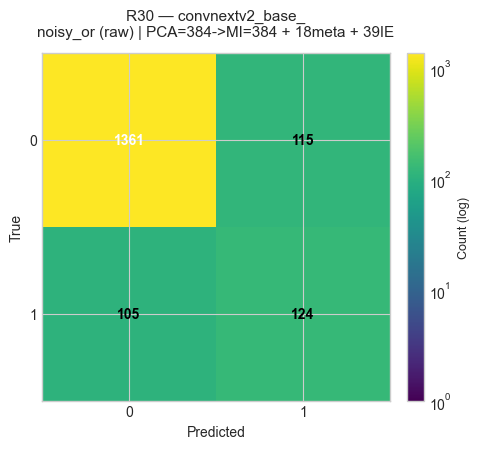

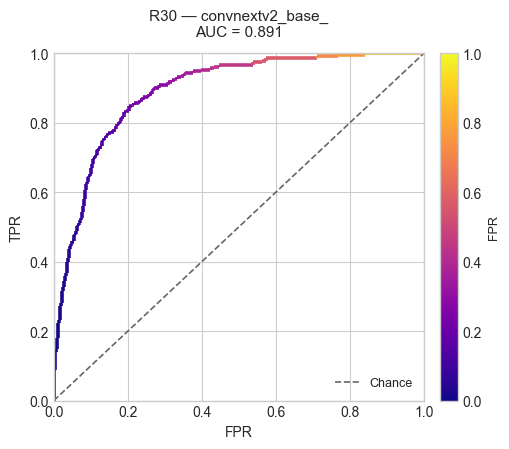


[2/7] R30 — dinov3_convnext_base
  PCA: 1024->384 (99.5% var)
  MI: 384->384
  Metadata: 18 features
  Inter-eye + norm: 39 features
  Dims: 384 PCA + 18 meta + 39 IE = 441
  [BayesSearchCV] 30 iters...
  CV F1=0.4292 | arch=(256,) | lr=0.000600 | w=10.00
  [Bagging] 25 models
  * Best: raw+noisy_or (val F1=0.5714, thresh=0.855)
  TEST: F1=0.5115  AUC=0.8739  BalAcc=0.7776
  CV-Test gap: -0.0823 | Val-Test gap: +0.0599
  Time: 481s
              precision    recall  f1-score   support

           0      0.952     0.826     0.884      1476
           1      0.394     0.729     0.511       229

    accuracy                          0.813      1705
   macro avg      0.673     0.778     0.698      1705
weighted avg      0.877     0.813     0.834      1705



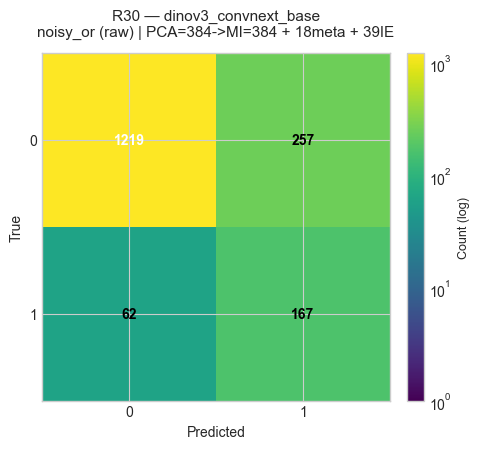

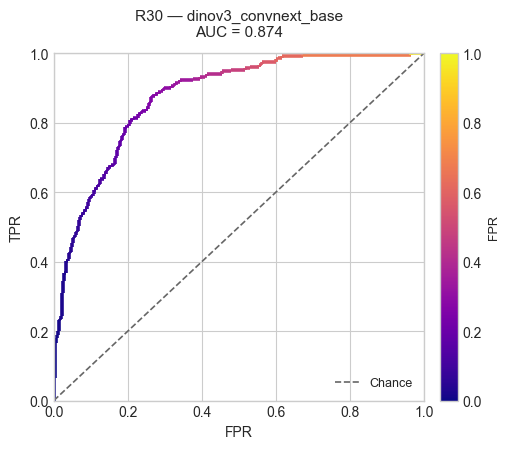


[3/7] R30 — dinov3_vitb16
  PCA: 768->384 (98.7% var)
  MI: 384->384
  Metadata: 18 features
  Inter-eye + norm: 39 features
  Dims: 384 PCA + 18 meta + 39 IE = 441
  [BayesSearchCV] 30 iters...
  CV F1=0.4730 | arch=(256, 128) | lr=0.002000 | w=4.62
  [Bagging] 25 models
  * Best: calibrated+noisy_or (val F1=0.6301, thresh=0.454)
  TEST: F1=0.5588  AUC=0.8829  BalAcc=0.7675
  CV-Test gap: -0.0857 | Val-Test gap: +0.0713
  Time: 457s
              precision    recall  f1-score   support

           0      0.941     0.902     0.921      1476
           1      0.500     0.633     0.559       229

    accuracy                          0.866      1705
   macro avg      0.720     0.767     0.740      1705
weighted avg      0.881     0.866     0.872      1705



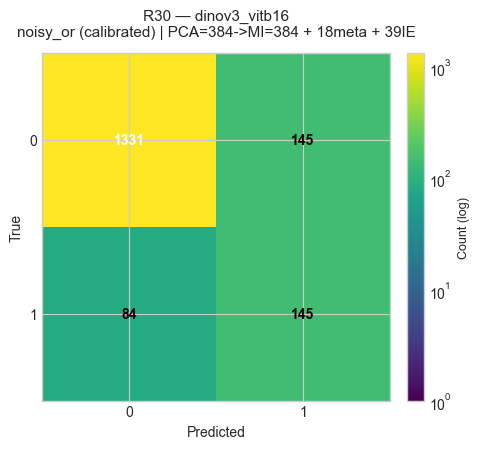

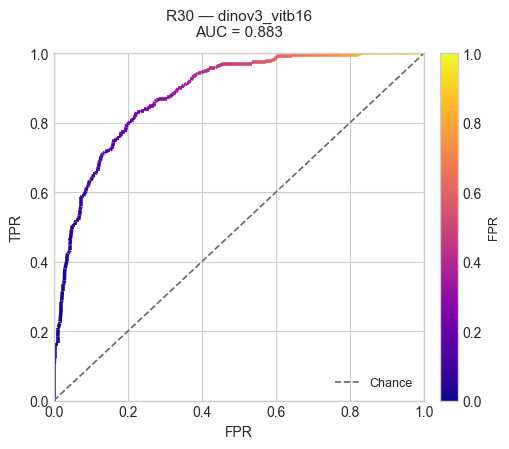


[4/7] R30 — RETFound_dinov2_shanghai
  PCA: 1024->384 (98.2% var)
  MI: 384->384
  Metadata: 18 features
  Inter-eye + norm: 39 features
  Dims: 384 PCA + 18 meta + 39 IE = 441
  [BayesSearchCV] 30 iters...
  CV F1=0.4552 | arch=(512,) | lr=0.000170 | w=6.30
  [Bagging] 25 models
  * Best: calibrated+noisy_or (val F1=0.6048, thresh=0.392)
  TEST: F1=0.5213  AUC=0.8697  BalAcc=0.7793
  CV-Test gap: -0.0661 | Val-Test gap: +0.0834
  Time: 1074s
              precision    recall  f1-score   support

           0      0.951     0.838     0.891      1476
           1      0.408     0.721     0.521       229

    accuracy                          0.822      1705
   macro avg      0.680     0.779     0.706      1705
weighted avg      0.878     0.822     0.841      1705



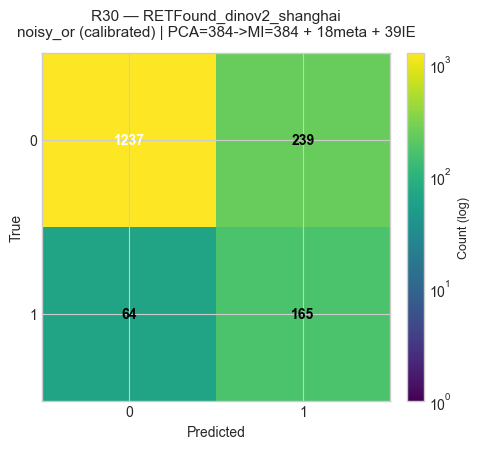

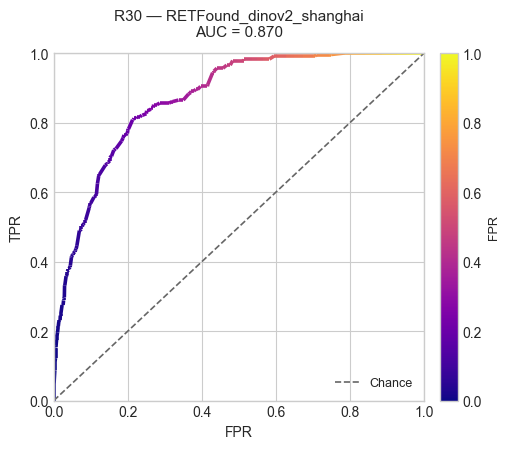


[5/7] R30 — RETFound_mae_natureCFP
  PCA: 1024->384 (99.3% var)
  MI: 384->384
  Metadata: 18 features
  Inter-eye + norm: 39 features
  Dims: 384 PCA + 18 meta + 39 IE = 441
  [BayesSearchCV] 30 iters...
  CV F1=0.4397 | arch=(256, 128) | lr=0.002000 | w=5.93
  [Bagging] 25 models
  * Best: raw+noisy_or (val F1=0.5742, thresh=0.893)
  TEST: F1=0.4688  AUC=0.8410  BalAcc=0.6950
  CV-Test gap: -0.0291 | Val-Test gap: +0.1054
  Time: 359s
              precision    recall  f1-score   support

           0      0.918     0.914     0.916      1476
           1      0.462     0.476     0.469       229

    accuracy                          0.855      1705
   macro avg      0.690     0.695     0.692      1705
weighted avg      0.857     0.855     0.856      1705



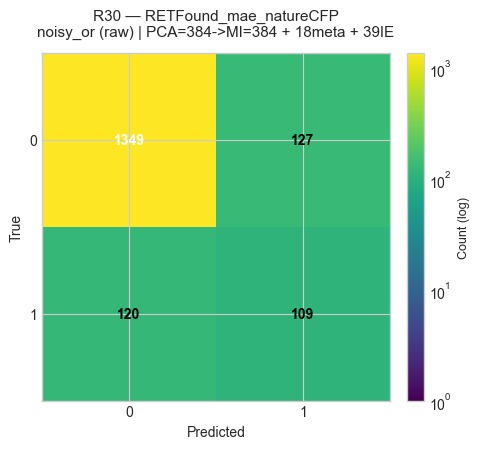

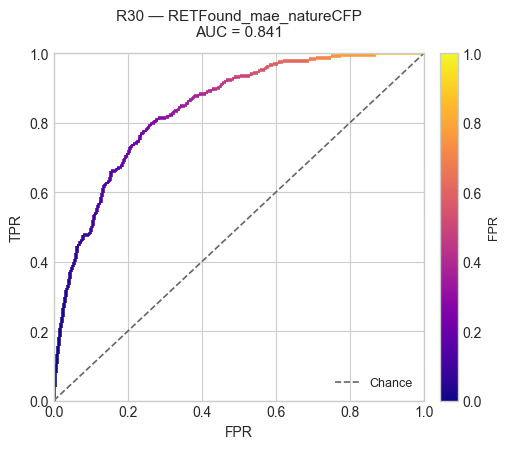


[6/7] R30 — RETFound_mae_shanghai
  PCA: 1024->384 (98.9% var)
  MI: 384->384
  Metadata: 18 features
  Inter-eye + norm: 39 features
  Dims: 384 PCA + 18 meta + 39 IE = 441
  [BayesSearchCV] 30 iters...
  CV F1=0.4535 | arch=(512,) | lr=0.000100 | w=5.29
  [Bagging] 25 models
  * Best: raw+noisy_or (val F1=0.6334, thresh=0.796)
  TEST: F1=0.4953  AUC=0.8514  BalAcc=0.7288
  CV-Test gap: -0.0418 | Val-Test gap: +0.1382
  Time: 753s
              precision    recall  f1-score   support

           0      0.930     0.886     0.907      1476
           1      0.437     0.572     0.495       229

    accuracy                          0.843      1705
   macro avg      0.683     0.729     0.701      1705
weighted avg      0.864     0.843     0.852      1705



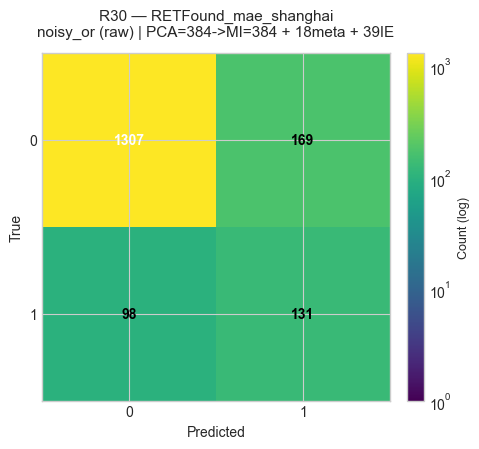

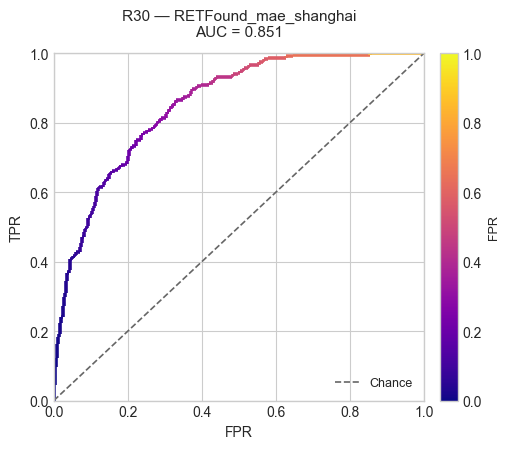


[7/7] R30 — vit_base_
  PCA: 768->384 (98.9% var)
  MI: 384->384
  Metadata: 18 features
  Inter-eye + norm: 39 features
  Dims: 384 PCA + 18 meta + 39 IE = 441
  [BayesSearchCV] 30 iters...
  CV F1=0.4549 | arch=(256, 128) | lr=0.002000 | w=5.15
  [Bagging] 25 models
  * Best: raw+max (val F1=0.5840, thresh=0.664)
  TEST: F1=0.4975  AUC=0.8495  BalAcc=0.7516
  CV-Test gap: -0.0426 | Val-Test gap: +0.0865
  Time: 401s
              precision    recall  f1-score   support

           0      0.941     0.848     0.892      1476
           1      0.401     0.655     0.498       229

    accuracy                          0.822      1705
   macro avg      0.671     0.752     0.695      1705
weighted avg      0.868     0.822     0.839      1705



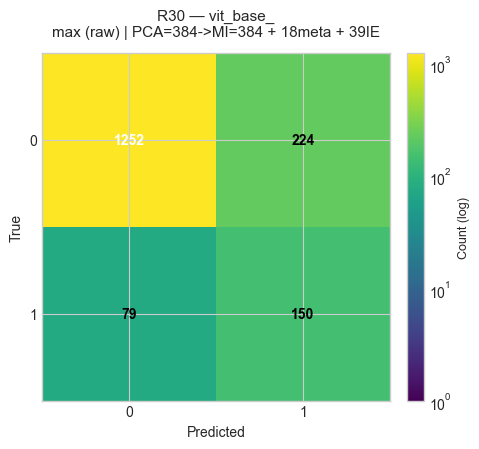

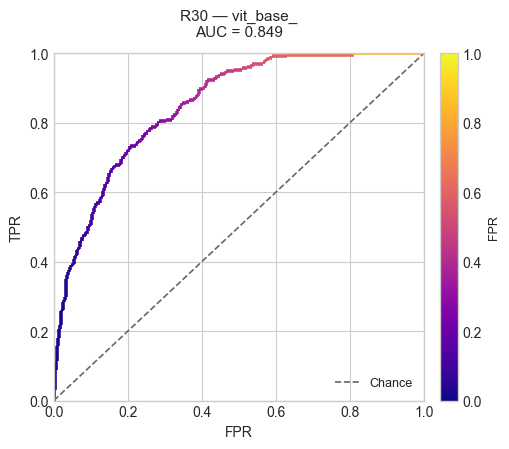


R30 complete! Total: 4207s (70.1 min)

-- R30 Per-Encoder Summary (sorted by F1) --
               embedding    cv_f1   val_f1       f1      auc  bal_acc  dim_mi  dim_meta  dim_ie best_agg
           dinov3_vitb16 0.473020 0.630058 0.558767 0.882916 0.767475     384        18      39 noisy_or
        convnextv2_base_ 0.476609 0.624161 0.529915 0.890927 0.731786     384        18      39 noisy_or
RETFound_dinov2_shanghai 0.455206 0.604775 0.521327 0.869692 0.779300     384        18      39 noisy_or
    dinov3_convnext_base 0.429171 0.571429 0.511485 0.873922 0.777569     384        18      39 noisy_or
               vit_base_ 0.454938 0.584022 0.497512 0.849460 0.751630     384        18      39      max
   RETFound_mae_shanghai 0.453491 0.633431 0.495274 0.851366 0.728777     384        18      39 noisy_or
  RETFound_mae_natureCFP 0.439701 0.574194 0.468817 0.840993 0.694970     384        18      39 noisy_or


In [7]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 5 — Per-Encoder MLP with Rich Metadata + Inter-Eye Features
#           (No OD masking — bilateral detection relies on embeddings
#            + inter-eye asymmetry, not per-eye optic disc status)
# ═══════════════════════════════════════════════════════════════════════

R30_DIR = RESULTS_DIR / 'r30_per_encoder'
R30_DIR.mkdir(parents=True, exist_ok=True)

print('=' * 80)
print('R30 — Per-Encoder MLP (PCA-384 + MI + Rich Meta + Inter-Eye, NO OD)')
print('=' * 80)

r30_results = []
t0_all = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Checkpoint: skip if results already exist ──────────────────
    chk_dir = R30_DIR / f'{emb_idx:02d}_{sname}'
    chk_hp  = chk_dir / 'hyperparameters.json'
    if chk_hp.exists():
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — CACHED')
        with open(chk_hp) as _f:
            prev = json.load(_f)
        tm = prev['test_metrics']
        r30_results.append({
            'embedding': sname,
            'dim_raw': prev.get('emb_dim_raw', 0), 'dim_pca': prev['pca_dim'],
            'dim_mi': prev['mi_selected'], 'pca_var': prev['pca_var'],
            'dim_meta': prev.get('meta_dim', 0),
            'dim_ie': prev.get('ie_dim', 0),
            'dim_total': prev.get('ndim', 0),
            'arch': prev['architecture'], 'alpha': prev['alpha'], 'lr': prev['lr'],
            'pos_weight': prev['pos_weight'], 'cv_f1': prev['best_cv_f1'],
            'val_f1': prev['best_val_f1'], 'best_agg': prev['best_agg'],
            'threshold': prev['threshold'], 'proba_type': prev['proba_type'],
            'f1': tm['f1'], 'auc': tm['auc'],
            'bal_acc': tm['bal_acc'],
            'precision': tm['precision'], 'recall': tm['recall'],
            'n_test_patients': tm['n_patients'],
            'time_s': 0,
        })
        continue

    print(f'\n{"="*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R30 — {sname}')
    print(f'{"="*80}')
    t0 = time.time()

    # ── Load & split ──────────────────────────────────────────────
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)
    if 'image_name' in df.columns:
        df['image_id'] = df['image_name'].str.replace(r'\.(jpg|png|jpeg)$', '', regex=True)

    # Merge referable_glaucoma label
    ref_label = labels_raw[['image_id', TASK]].drop_duplicates(subset='image_id')
    df = df.merge(ref_label, on='image_id', how='left')
    df[TASK] = df[TASK].fillna(0).astype(int)

    # Merge rich metadata (drop overlapping cols first to avoid _x/_y suffixes)
    meta_merge_cols = ['image_id'] + [c for c in meta_keep if c != 'image_id' and c != TASK]
    meta_src = labels_raw[meta_merge_cols].drop_duplicates(subset='image_id')
    overlap = [c for c in meta_src.columns if c in df.columns and c != 'image_id']
    df = df.drop(columns=overlap, errors='ignore')
    df = df.merge(meta_src, on='image_id', how='left')

    # Merge inter-eye + norm features from FE
    ie_merge = fe_df[['image_id', 'patient_id'] + IE_COLS + NORM_COLS].copy()
    df = df.merge(ie_merge, on=['image_id', 'patient_id'], how='left', suffixes=('', '_fe'))

    # Split
    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # ── PCA ───────────────────────────────────────────────────────
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}->{nc} ({var_exp:.1%} var)')

    # ── MI Selection ──────────────────────────────────────────────
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask, mi_scores = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS,
            random_state=RANDOM_SEED,
        )
        n_kept = mi_mask.sum()
        print(f'  MI: {nc}->{n_kept}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca
        n_kept = nc

    # ── Rich metadata (18 features) ──────────────────────────────
    X_tr_meta, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)
    meta_dim = X_tr_meta.shape[1]
    print(f'  Metadata: {meta_dim} features')

    # ── Inter-eye + norm features (35 + 4) ────────────────────────
    X_tr_ie, ie_stats = encode_inter_eye_features(b_train, IE_COLS, NORM_COLS)
    X_va_ie, _        = encode_inter_eye_features(b_val, IE_COLS, NORM_COLS, fit_stats=ie_stats)
    X_te_ie, _        = encode_inter_eye_features(b_test, IE_COLS, NORM_COLS, fit_stats=ie_stats)
    ie_dim = X_tr_ie.shape[1]
    print(f'  Inter-eye + norm: {ie_dim} features')

    # ── Feature assembly (NO OD masking) ──────────────────────────
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, X_tr_ie])
    X_va_full = np.hstack([X_va_sel, X_va_meta, X_va_ie])
    X_te_full = np.hstack([X_te_sel, X_te_meta, X_te_ie])
    ndim = X_tr_full.shape[1]
    print(f'  Dims: {n_kept} PCA + {meta_dim} meta + {ie_dim} IE = {ndim}')

    # ── Scale ─────────────────────────────────────────────────────
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_va_s = scaler.transform(X_va_full)
    X_te_s = scaler.transform(X_te_full)

    # ── BayesSearchCV ─────────────────────────────────────────────
    print(f'  [BayesSearchCV] {BAYES_N_ITER} iters...')
    base_est = MLPWrapperForBayesSearch(
        max_iter=MLP_MAX_ITER, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
        random_state=RANDOM_SEED,
    )
    bayes = BayesSearchCV(
        estimator=base_est, search_spaces=SEARCH_SPACE,
        n_iter=BAYES_N_ITER, cv=BAYES_CV_FOLDS,
        n_jobs=BAYES_N_JOBS, scoring='f1',
        random_state=RANDOM_SEED, verbose=0,
    )
    bayes.fit(X_tr_s, yb_train)

    bp = bayes.best_params_
    bcv_f1 = bayes.best_score_
    ai = bp.get('hidden_layer_sizes', 0)
    barch = ARCHITECTURE_OPTIONS[ai] if isinstance(ai, int) else ai
    balpha = bp['alpha']
    blr    = bp['learning_rate_init']
    bbs    = bp['batch_size']
    bw     = bp['pos_class_weight']
    print(f'  CV F1={bcv_f1:.4f} | arch={barch} | lr={blr:.6f} | w={bw:.2f}')

    # ── Bagging ───────────────────────────────────────────────────
    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]
    print(f'  [Bagging] {N_BAGS} models')

    cal_p, cal_l = {}, {}
    bag_val_preds = []
    bag_test_preds = []

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m_bag = np.isin(pids_tr, list(itr_pids))
        va_m_bag = np.isin(pids_tr, list(iva_pids))

        X_it = scaler.transform(np.hstack([
            X_tr_sel[tr_m_bag], X_tr_meta[tr_m_bag], X_tr_ie[tr_m_bag]]))
        y_it = yb_train[tr_m_bag]

        X_iv = scaler.transform(np.hstack([
            X_tr_sel[va_m_bag], X_tr_meta[va_m_bag], X_tr_ie[va_m_bag]]))
        y_iv = yb_train[va_m_bag]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v, alpha=balpha,
                learning_rate='adaptive',
                learning_rate_init=blr, batch_size=bbs,
                max_iter=MLP_MAX_ITER, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
                random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_it, bw)
            mlp.fit(X_it, y_it, sample_weight=sw)
            svp.append(mlp.predict_proba(X_iv)[:, 1])

            bag_val_preds.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_test_preds.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    # ── Calibration ───────────────────────────────────────────────
    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_v_cal = iso.predict(np.mean(bag_val_preds, axis=0))
    avg_t_cal = iso.predict(np.mean(bag_test_preds, axis=0))
    avg_v_raw = np.mean(bag_val_preds, axis=0)
    avg_t_raw = np.mean(bag_test_preds, axis=0)

    # ── Threshold sweep on FIXED VAL ──────────────────────────────
    plv = aggregate_patient_labels(pids_va, yb_val)
    b_agg, b_f1v, b_thr, b_pt = 'mean', 0.0, 0.5, 'calibrated'
    for ptn, vp in [('calibrated', avg_v_cal), ('raw', avg_v_raw)]:
        for agg in AGG_METHODS:
            pp = aggregate_patient_proba(pids_va, vp, method=agg)
            com = pp.index.intersection(plv.index)
            t, f = find_optimal_threshold(plv.loc[com].values, pp.loc[com].values,
                                         grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR)
            if f > b_f1v:
                b_f1v, b_agg, b_thr, b_pt = f, agg, t, ptn

    print(f'  * Best: {b_pt}+{b_agg} (val F1={b_f1v:.4f}, thresh={b_thr:.3f})')

    # ── Evaluate on TEST ──────────────────────────────────────────
    plt_te = aggregate_patient_labels(pids_te, yb_test)
    tp = avg_t_cal if b_pt == 'calibrated' else avg_t_raw
    pp = aggregate_patient_proba(pids_te, tp, method=b_agg)
    com = pp.index.intersection(plt_te.index)
    yt = plt_te.loc[com].values
    yp = pp.loc[com].values
    yh = (yp >= b_thr).astype(int)
    test_metrics = {
        'f1': float(f1_score(yt, yh, zero_division=0)),
        'precision': float(precision_score(yt, yh, zero_division=0)),
        'recall': float(recall_score(yt, yh, zero_division=0)),
        'auc': float(roc_auc_score(yt, yp)),
        'bal_acc': float(balanced_accuracy_score(yt, yh)),
        'n_patients': int(len(com)),
    }

    elapsed = time.time() - t0
    print(f'  TEST: F1={test_metrics["f1"]:.4f}  AUC={test_metrics["auc"]:.4f}  '
          f'BalAcc={test_metrics["bal_acc"]:.4f}')
    print(f'  CV-Test gap: {bcv_f1 - test_metrics["f1"]:+.4f} | '
          f'Val-Test gap: {b_f1v - test_metrics["f1"]:+.4f}')
    print(f'  Time: {elapsed:.0f}s')

    # ── Save per-encoder ──────────────────────────────────────────
    out_dir = R30_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(yt, yh)
    rep = classification_report(yt, yh, digits=3)
    fpr_c, tpr_c, _ = roc_curve(yt, yp)
    print(rep)

    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix.csv', index=False)
    (out_dir / 'classification_report.txt').write_text(rep, encoding='utf-8')
    pd.DataFrame({'fpr': fpr_c, 'tpr': tpr_c}).to_csv(out_dir / 'roc_curve.csv', index=False)
    pd.DataFrame({
        'patient_id': com, 'y_true': yt, 'y_pred': yh, 'y_proba': yp,
    }).to_csv(out_dir / 'patient_predictions.csv', index=False)

    hp = {
        'track': 'R30', 'embedding': sname, 'architecture': str(barch),
        'alpha': float(balpha), 'lr': float(blr), 'batch_size': int(bbs),
        'pos_weight': float(bw), 'best_cv_f1': float(bcv_f1),
        'best_val_f1': float(b_f1v), 'best_agg': b_agg, 'threshold': float(b_thr),
        'proba_type': b_pt, 'pca_dim': nc, 'mi_selected': int(n_kept),
        'pca_var': float(var_exp), 'n_bags': N_BAGS,
        'emb_dim_raw': emb_dim_raw, 'ndim': ndim,
        'meta_dim': meta_dim, 'ie_dim': ie_dim,
        'test_metrics': test_metrics,
    }
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp, f, indent=2)

    plot_confusion_matrix(cm,
        title=f'R30 — {sname}\n{b_agg} ({b_pt}) | PCA={nc}->MI={n_kept} + {meta_dim}meta + {ie_dim}IE',
        save_path=out_dir / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr_c, tpr_c, test_metrics['auc'],
        title=f'R30 — {sname}',
        save_path=out_dir / 'roc_curve.png', show=True)

    r30_results.append({
        'embedding': sname,
        'dim_raw': emb_dim_raw, 'dim_pca': nc, 'dim_mi': int(n_kept),
        'pca_var': float(var_exp), 'dim_meta': meta_dim, 'dim_ie': ie_dim,
        'dim_total': ndim,
        'arch': str(barch), 'alpha': float(balpha), 'lr': float(blr),
        'pos_weight': float(bw), 'cv_f1': float(bcv_f1),
        'val_f1': float(b_f1v), 'best_agg': b_agg, 'threshold': float(b_thr),
        'proba_type': b_pt,
        'f1': test_metrics['f1'], 'auc': test_metrics['auc'],
        'bal_acc': test_metrics['bal_acc'],
        'precision': test_metrics['precision'], 'recall': test_metrics['recall'],
        'n_test_patients': test_metrics['n_patients'],
        'time_s': float(elapsed),
    })

total = time.time() - t0_all
print(f'\n{"="*80}')
print(f'R30 complete! Total: {total:.0f}s ({total/60:.1f} min)')
print(f'{"="*80}')

# Save summary
r30_df = pd.DataFrame(r30_results).sort_values('f1', ascending=False)
r30_df.to_csv(R30_DIR / 'r30_summary.csv', index=False)

print('\n-- R30 Per-Encoder Summary (sorted by F1) --')
show_cols = ['embedding', 'cv_f1', 'val_f1', 'f1', 'auc', 'bal_acc',
             'dim_mi', 'dim_meta', 'dim_ie', 'best_agg']
print(r30_df[[c for c in show_cols if c in r30_df.columns]].to_string(index=False))

---
## R30 — Loss Curves

Retrain one MLP per encoder to capture training loss curves.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 6 — Loss Curves (per encoder)
# ═══════════════════════════════════════════════════════════════════════

enc_dirs = sorted([d for d in R30_DIR.iterdir()
                   if d.is_dir() and (d / 'hyperparameters.json').exists()])

if not enc_dirs:
    print('No R30 results found — run Cell 5 first.')
else:
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    axes = axes.flatten()

    for idx, ed in enumerate(enc_dirs):
        hp = json.loads((ed / 'hyperparameters.json').read_text())
        sn = hp['embedding']
        arch_lc = eval(hp['architecture'])

        # Reload data for this encoder
        emb_path_lc = [p for p in embedding_files if short_name(p) == sn]
        if not emb_path_lc:
            continue
        ds_lc = load_retina_embeddings_dataset(
            dataset=DATASET_NAME, embeddings_csv_path=str(emb_path_lc[0]),
            labels_csv_path=str(LABELS_PATH),
        )
        df_lc = ds_lc.df.copy()
        df_lc['patient_id'] = df_lc['patient_id'].astype(str)
        if 'image_name' in df_lc.columns:
            df_lc['image_id'] = df_lc['image_name'].str.replace(r'\.(jpg|png|jpeg)$', '', regex=True)

        ref_lbl = labels_raw[['image_id', TASK]].drop_duplicates(subset='image_id')
        df_lc = df_lc.merge(ref_lbl, on='image_id', how='left')
        df_lc[TASK] = df_lc[TASK].fillna(0).astype(int)
        meta_merge_lc = ['image_id'] + [c for c in meta_keep if c != 'image_id' and c != TASK]
        meta_src_lc = labels_raw[meta_merge_lc].drop_duplicates(subset='image_id')
        overlap_lc = [c for c in meta_src_lc.columns if c in df_lc.columns and c != 'image_id']
        df_lc = df_lc.drop(columns=overlap_lc, errors='ignore')
        df_lc = df_lc.merge(meta_src_lc, on='image_id', how='left')
        ie_merge_lc = fe_df[['image_id', 'patient_id'] + IE_COLS + NORM_COLS].copy()
        df_lc = df_lc.merge(ie_merge_lc, on=['image_id', 'patient_id'], how='left', suffixes=('', '_fe'))

        tr_lc = df_lc[df_lc['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
        X_emb_lc = tr_lc[ds_lc.feature_cols].to_numpy(dtype=np.float32)
        y_lc = tr_lc[TASK].to_numpy(dtype=int)

        nc_lc = min(PCA_COMPONENTS, X_emb_lc.shape[1], X_emb_lc.shape[0])
        pca_lc = PCA(n_components=nc_lc, random_state=RANDOM_SEED)
        X_pca_lc = pca_lc.fit_transform(X_emb_lc)
        if MI_SELECTION:
            X_sel_lc, _, _, _ = mi_select_features(X_pca_lc, y_lc, [],
                percentile_thresh=MI_PERCENTILE_THRESH, min_components=MI_MIN_COMPONENTS,
                random_state=RANDOM_SEED)
        else:
            X_sel_lc = X_pca_lc

        X_meta_lc, _ = encode_metadata(tr_lc, METADATA_COLS)
        X_ie_lc, _ = encode_inter_eye_features(tr_lc, IE_COLS, NORM_COLS)

        X_full_lc = np.hstack([X_sel_lc, X_meta_lc, X_ie_lc])
        scaler_lc = StandardScaler()
        X_s_lc = scaler_lc.fit_transform(X_full_lc)

        mlp_lc = MLPClassifier(
            hidden_layer_sizes=arch_lc, alpha=hp['alpha'],
            learning_rate='adaptive', learning_rate_init=hp['lr'],
            batch_size=hp['batch_size'], max_iter=600,
            early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=MLP_PATIENCE, random_state=RANDOM_SEED,
            warm_start=True,
        )

        losses = []
        for step in range(60):
            mlp_lc.max_iter = (step + 1) * 10
            sw_lc = make_sample_weights(y_lc, hp['pos_weight'])
            mlp_lc.fit(X_s_lc, y_lc, sample_weight=sw_lc)
            losses.append(mlp_lc.loss_)
            if hasattr(mlp_lc, 'n_iter_') and mlp_lc.n_iter_ < mlp_lc.max_iter:
                break

        ax = axes[idx] if idx < len(axes) else axes[-1]
        ax.plot(range(1, len(losses)+1), losses, 'o-', color='#E76F51', lw=1.5, markersize=3)
        ax.set_title(f'{sn[:20]}', fontsize=9)
        ax.set_xlabel('Step'); ax.set_ylabel('Loss')
        ax.grid(alpha=0.3)

    # Hide unused axes
    for i in range(len(enc_dirs), len(axes)):
        axes[i].set_visible(False)

    fig.suptitle('R30 — Per-Encoder Loss Curves (no OD masking)', fontsize=14, y=1.02)
    plt.tight_layout()
    fig.savefig(R30_DIR / 'loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Loss curves saved.')

---
## R30 vs R29 Comparison

Compare each encoder's R30 result (with rich metadata + inter-eye features)
against its R29 result (with only 5 metadata features).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 7 — R30 vs R29 Comparison
# ═══════════════════════════════════════════════════════════════════════

r29_path = R29_SUMMARY
r30_path = R30_DIR / 'r30_summary.csv'

if r29_path.exists() and r30_path.exists():
    r29 = pd.read_csv(r29_path)
    r30 = pd.read_csv(r30_path)

    # R30 now uses flat column names (no P25 suffix)
    comp = r30[['embedding', 'f1', 'auc', 'bal_acc', 'dim_meta', 'dim_ie']].copy()
    comp = comp.rename(columns={'f1': 'r30_f1', 'auc': 'r30_auc', 'bal_acc': 'r30_ba'})

    # R29 still uses P25 column names
    r29_sub = r29[['embedding', 'f1_P25', 'auc_P25', 'bal_acc_P25']].copy()
    r29_sub = r29_sub.rename(columns={'f1_P25': 'r29_f1', 'auc_P25': 'r29_auc', 'bal_acc_P25': 'r29_ba'})

    comp = comp.merge(r29_sub, on='embedding', how='left')
    comp['dF1'] = comp['r30_f1'] - comp['r29_f1']
    comp['dAUC'] = comp['r30_auc'] - comp['r29_auc']
    comp = comp.sort_values('r30_f1', ascending=False)

    print('=' * 90)
    print('R30 vs R29 — Per-Encoder Comparison (sorted by R30 F1)')
    print('=' * 90)
    print(comp.to_string(index=False))

    avg_df1 = comp['dF1'].mean()
    avg_dauc = comp['dAUC'].mean()
    n_improved = (comp['dF1'] > 0).sum()
    print(f'\nAverage dF1: {avg_df1:+.4f}  |  Average dAUC: {avg_dauc:+.4f}')
    print(f'Improved: {n_improved}/{len(comp)} encoders')
    print(f'Best R30 F1: {comp["r30_f1"].max():.4f}  (target: >= 0.80)')

    # Bar chart
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    x = np.arange(len(comp))
    w = 0.35
    for i, (metric, r30c, r29c, title) in enumerate([
        ('F1', 'r30_f1', 'r29_f1', 'F1 Score'),
        ('AUC', 'r30_auc', 'r29_auc', 'AUC')]):
        ax = axes[i]
        ax.barh(x - w/2, comp[r29c].values, w, label='R29 (5 meta + OD)', color='#457B9D', alpha=0.8)
        ax.barh(x + w/2, comp[r30c].values, w, label='R30 (18 meta + IE, no OD)', color='#2D6A4F', alpha=0.8)
        ax.set_yticks(x); ax.set_yticklabels([e[:18] for e in comp['embedding']], fontsize=8)
        ax.set_xlabel(title)
        ax.set_title(f'R30 vs R29 — {title}', fontsize=13)
        for j, (v29, v30) in enumerate(zip(comp[r29c].values, comp[r30c].values)):
            ax.text(max(v29, v30) + 0.003, j, f'{v30-v29:+.3f}', va='center', fontsize=7,
                    color='green' if v30 > v29 else 'red')
        ax.legend(fontsize=8)
        ax.grid(axis='x', alpha=0.3)
        if metric == 'F1':
            ax.axvline(0.80, ls='--', color='red', lw=1.5, alpha=0.7, label='Target F1=0.80')

    plt.tight_layout()
    fig.savefig(RESULTS_DIR / 'r30_vs_r29_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    comp.to_csv(RESULTS_DIR / 'r30_vs_r29_comparison.csv', index=False)
    print(f'Saved comparison to {RESULTS_DIR}')
else:
    print('Missing R29 or R30 summary — run training cells first.')

## Interpretation Notes

**R30 improvements over R29 (same per-encoder pipeline):**
- **Rich metadata (18 vs 5 features):** vessels, macula, image quality flags, DR severity, pathology flags
- **Inter-eye asymmetry features (35+4):** cosine/L2 distance between OD and OS embeddings per encoder
- **No optic_disc masking:** OD masking was removed because for **bilateral** (referable) glaucoma detection, optic_disc status tells about THIS eye — it cannot help distinguish unilateral from bilateral. Removing OD noise lets the model focus on embedding features + inter-eye asymmetry.
- **More aggressive MI filtering (30% vs 15%):** Forces the model to focus on the most informative PCA components
- **No cross-encoder fusion** — each encoder evaluated independently, same as R28/R29

**Note on data leakage:**
- `optic_disc` → NOT used as feature (removed from pipeline entirely)
- `increased_cup_disc` → label source, NEVER used as feature
- All other clinical findings (vessels, macula, DR, etc.) assess DIFFERENT structures/pathways

---
## R30 — Validation Suite

Same 5-test validation as R29: Bootstrap CIs, Calibration, Subgroup Fairness, Inter-Encoder Agreement, Error Analysis.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 8 — Validation Suite (R30 Per-Encoder)
# ═══════════════════════════════════════════════════════════════════════

import json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, brier_score_loss, cohen_kappa_score
from sklearn.calibration import calibration_curve
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

BASE    = Path.cwd()
R30_DIR_VS = BASE / 'results' / 'brset_r30_rich_meta_referable_glaucoma' / 'r30_per_encoder'
R29_DIR_VS = BASE / 'results' / 'brset_r29_referable_glaucoma' / 'r29_per_encoder'
LAB     = BASE / 'data' / 'brset_embeddings' / 'brset_labels' / 'labels_brset.csv'
VS_DIR  = R30_DIR_VS / 'validation_suite'
VS_DIR.mkdir(exist_ok=True)

# Load all R30 per-encoder predictions
r30_enc_dirs = sorted([d for d in R30_DIR_VS.iterdir()
                       if d.is_dir() and d.name != 'validation_suite'])
all_preds = {}
for ed in r30_enc_dirs:
    pp = ed / 'patient_predictions.csv'
    if pp.exists():
        df = pd.read_csv(pp)
        df['patient_id'] = df['patient_id'].astype(str)
        hp = json.loads((ed / 'hyperparameters.json').read_text())
        all_preds[hp['embedding']] = df

print(f'Loaded {len(all_preds)} R30 encoder predictions')

# Load labels for subgroup analysis
lab_raw = pd.read_csv(LAB)
lab_raw['patient_id'] = lab_raw['patient_id'].astype(str)
lab_raw = lab_raw.rename(columns={'patient_age': 'age', 'patient_sex': 'sex'})
pat_meta = lab_raw.groupby('patient_id').first()[['age','sex','diabetes','camera']].reset_index()

summary = []

# ═══════════════════════════════════════════════════════════════════
# TEST 1: Bootstrap CIs
# ═══════════════════════════════════════════════════════════════════
print('\n' + '='*80)
print('TEST 1 — Bootstrap 95% Confidence Intervals')
print('='*80)

B = 2000
ci_rows = []
for name, df in all_preds.items():
    yt = df['y_true'].values; yp = df['y_proba'].values; yh = df['y_pred'].values
    n = len(yt)
    rng = np.random.default_rng(42)
    f1s, aucs = [], []
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(yt[idx])) < 2: continue
        f1s.append(f1_score(yt[idx], yh[idx], zero_division=0))
        aucs.append(roc_auc_score(yt[idx], yp[idx]))
    f1_lo, f1_hi = np.percentile(f1s, [2.5, 97.5])
    auc_lo, auc_hi = np.percentile(aucs, [2.5, 97.5])
    ci_rows.append({'encoder': name,
                    'f1_point': f1_score(yt, yh, zero_division=0),
                    'f1_lo': f1_lo, 'f1_hi': f1_hi, 'f1_width': f1_hi-f1_lo,
                    'auc_point': roc_auc_score(yt, yp),
                    'auc_lo': auc_lo, 'auc_hi': auc_hi, 'auc_width': auc_hi-auc_lo})
    print(f'  {name:<30} F1={f1_score(yt,yh,zero_division=0):.3f} [{f1_lo:.3f},{f1_hi:.3f}]  '
          f'AUC={roc_auc_score(yt,yp):.3f} [{auc_lo:.3f},{auc_hi:.3f}]')

ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(VS_DIR / 'test1_bootstrap_ci.csv', index=False)

max_ci_width = ci_df['f1_width'].max()
t1_pass = max_ci_width < 0.10
summary.append(('T1: Bootstrap CI', 'PASS' if t1_pass else 'WATCH', f'max CI width={max_ci_width:.3f}'))

# ═══════════════════════════════════════════════════════════════════
# TEST 2: Calibration
# ═══════════════════════════════════════════════════════════════════
print('\n' + '='*80)
print('TEST 2 — Calibration (Brier Score)')
print('='*80)

brier_scores = {}
for name, df in all_preds.items():
    yt = df['y_true'].values; yp = df['y_proba'].values
    bs = brier_score_loss(yt, yp)
    brier_scores[name] = bs
    print(f'  {name:<30} Brier={bs:.4f}')

max_brier = max(brier_scores.values())
t2_pass = max_brier < 0.25
summary.append(('T2: Calibration', 'PASS' if t2_pass else 'WATCH', f'max Brier={max_brier:.3f}'))

# ═══════════════════════════════════════════════════════════════════
# TEST 3: Subgroup Fairness
# ═══════════════════════════════════════════════════════════════════
print('\n' + '='*80)
print('TEST 3 — Subgroup Fairness')
print('='*80)

worst_gap = 0.0
fair_rows = []
for name, df in all_preds.items():
    df2 = df.merge(pat_meta, on='patient_id', how='left')
    for attr in ['sex', 'camera', 'diabetes']:
        if attr not in df2.columns or df2[attr].nunique() < 2: continue
        groups = df2.groupby(attr)
        g_f1 = {}
        for gname, gdf in groups:
            if len(gdf) < 10 or gdf['y_true'].nunique() < 2: continue
            g_f1[str(gname)] = f1_score(gdf['y_true'], gdf['y_pred'], zero_division=0)
        if len(g_f1) >= 2:
            vals = list(g_f1.values())
            gap = max(vals) - min(vals)
            worst_gap = max(worst_gap, gap)
            fair_rows.append({'encoder': name, 'attribute': attr, 'groups': str(g_f1), 'gap': gap})

pd.DataFrame(fair_rows).to_csv(VS_DIR / 'test3_subgroup_fairness.csv', index=False)
t3_pass = worst_gap < 0.15
summary.append(('T3: Subgroup Fairness', 'PASS' if t3_pass else 'WATCH', f'worst gap={worst_gap:.3f}'))
print(f'  Worst gap: {worst_gap:.3f}')

# ═══════════════════════════════════════════════════════════════════
# TEST 4: Inter-Encoder Agreement
# ═══════════════════════════════════════════════════════════════════
print('\n' + '='*80)
print('TEST 4 — Inter-Encoder Agreement (Kappa)')
print('='*80)

enc_names = list(all_preds.keys())
kappa_rows = []
for i in range(len(enc_names)):
    for j in range(i+1, len(enc_names)):
        n1, n2 = enc_names[i], enc_names[j]
        d1 = all_preds[n1].set_index('patient_id')
        d2 = all_preds[n2].set_index('patient_id')
        com = d1.index.intersection(d2.index)
        if len(com) > 0:
            k = cohen_kappa_score(d1.loc[com, 'y_pred'], d2.loc[com, 'y_pred'])
            kappa_rows.append({'enc_a': n1, 'enc_b': n2, 'kappa': k})

kappa_df = pd.DataFrame(kappa_rows)
if not kappa_df.empty:
    kappa_df.to_csv(VS_DIR / 'test4_inter_encoder_kappa.csv', index=False)
    mean_kappa = kappa_df['kappa'].mean()

    # Unanimous agreement
    ref_enc = enc_names[0]
    ref_df = all_preds[ref_enc].set_index('patient_id')
    com_all = ref_df.index
    for en in enc_names[1:]:
        com_all = com_all.intersection(all_preds[en].set_index('patient_id').index)
    if len(com_all) > 0:
        votes = np.column_stack([all_preds[en].set_index('patient_id').loc[com_all, 'y_pred'].values
                                  for en in enc_names])
        unanimous = (votes.sum(axis=1) == 0) | (votes.sum(axis=1) == len(enc_names))
        unan_rate = unanimous.mean()
        print(f'  Unanimous agreement: {unan_rate:.1%} ({unanimous.sum()}/{len(com_all)})')
    print(f'  Mean kappa: {mean_kappa:.3f}')
else:
    mean_kappa = 0
    unan_rate = 0

t4_pass = mean_kappa > 0.5
summary.append(('T4: Inter-Encoder Agree', 'PASS' if t4_pass else 'WATCH', f'mean kappa={mean_kappa:.3f}'))

# ═══════════════════════════════════════════════════════════════════
# TEST 5: Error Analysis
# ═══════════════════════════════════════════════════════════════════
print('\n' + '='*80)
print('TEST 5 — Error Analysis')
print('='*80)

hard_fn_all = None
for name, df in all_preds.items():
    fn_pids = set(df[(df['y_true']==1) & (df['y_pred']==0)]['patient_id'])
    fp_pids = set(df[(df['y_true']==0) & (df['y_pred']==1)]['patient_id'])
    print(f'  {name:<30} FP={len(fp_pids)}  FN={len(fn_pids)}')
    if hard_fn_all is None:
        hard_fn_all = fn_pids
    else:
        hard_fn_all &= fn_pids

print(f'  Hard FN (missed by ALL): {len(hard_fn_all)} patients')
t5_pass = len(hard_fn_all) < 100
summary.append(('T5: Error Analysis', 'PASS' if t5_pass else 'WATCH', f'{len(hard_fn_all)} hard FN'))

# ═══════════════════════════════════════════════════════════════════
# SUMMARY
# ═══════════════════════════════════════════════════════════════════
print('\n' + '='*80)
print('R30 VALIDATION SUITE — SUMMARY')
print('='*80)
for name, status, detail in summary:
    marker = '+' if status == 'PASS' else '!'
    print(f'  [{marker}] {name:<25} {status:<6} {detail}')

n_pass = sum(1 for _, s, _ in summary if s == 'PASS')
n_watch = sum(1 for _, s, _ in summary if s == 'WATCH')
print(f'\n  Result: {n_pass} PASS / {n_watch} WATCH')
print(f'  Saved to: {VS_DIR}')